# Sentiment Analysis of Tweets on Tech Products

# Chapter 1: Business Understanding

## 1.1 Background Information

In today’s digital age, consumers constantly share their opinions online about various topics an products through reviews, tweets, and forums. These opinions hold valuable insights for technology companies that rely heavily on user experience and brand perception. Understanding public sentiment helps firms make data-driven product, marketing, and customer experience decisions.

This project is undertaken by Lingua Franca Data Elites, a data-driven consulting firm specializing in artificial intelligence solutions for business intelligence and brand analytics. Lingua Franca has been contracted to conduct a sentiment analysis on customer reviews and discussions surrounding Google and Apple products. With both brands dominating the global tech landscape, analyzing how customers perceive their products across online platforms can reveal comparative advantages, recurring complaints, and evolving brand loyalty trends.

The motivation for this analysis arises from the increasing competition in the consumer technology market. Both Google and Apple continuously release innovative hardware and software products, yet their customer satisfaction levels and public sentiment fluctuate based on product performance, pricing, design, and ecosystem integration. Understanding these sentiments provides an opportunity for firms and investors to forecast brand performance, guide marketing strategies, and identify product improvement areas.

--- 


## 1.2 Problem Statement

Despite the abundance of online reviews and discussions, companies often struggle to systematically analyze this data to extract actionable insights. Manual review analysis is time-consuming, subjective, and impractical given the volume of data generated daily.

This project aims to develop a Natural Language Processing (NLP) model that automatically classifies and interprets user sentiment (positive, negative, or neutral) toward Google and Apple products. By analyzing patterns and themes within the text data, the project seeks to answer key business questions such as:

* How do users perceive Google versus Apple products in terms of satisfaction and quality?
* What product features drive the strongest positive or negative emotions?
* How has sentiment evolved over time for each brand?
* Are there recurring issues or praise patterns that can inform future product development and customer engagement?

---

## 1.3 Project Objectives

### General Objective:

To build and evaluate an NLP model capable of accurately predicting and interpreting customer sentiment regarding Google and Apple products, providing actionable insights for strategic decision-making.

### Specific Objectives:

1. To perform data cleaning and exploratory data analysis to understand trends and key topics in user reviews.
2. To develop a baseline machine learning model (TF-IDF + Logistic Regression) for sentiment classification.
3. To fine-tune a transformer-based NLP model (e.g., BERT or DistilBERT) for improved sentiment prediction accuracy.
4. To conduct error and interpretability analysis to understand which words or phrases drive sentiment outcomes.
5. To compare sentiment distributions between Google and Apple products and highlight areas of strength or improvement for each brand.
6. To visualize sentiment trends and generate a dashboard/report for business stakeholders.

---

##  1.4 Metrics of Success

The success of this sentiment analysis project will be evaluated using both **quantitative model performance metrics** and **qualitative business outcomes**, each with clear numerical targets to guide model development and evaluation.

---

### a) Model Performance Metrics

| **Metric** | **Definition / Purpose** | **Baseline Target (TF-IDF + Logistic Regression)** | **Advanced Model Target (DistilBERT/BERT)** | **Business Interpretation** |
|-------------|---------------------------|----------------------------------------------------|---------------------------------------------|-----------------------------|
| **Accuracy** | Proportion of correctly classified reviews. | ≥ **75%** | ≥ **85–90%** | Reflects overall reliability in labeling sentiments correctly. |
| **Precision (Positive Class)** | Out of all predicted positive reviews, how many are actually positive. | ≥ **70%** | ≥ **85%** | High precision means fewer false positives — ideal for confident marketing insights. |
| **Recall (Negative Class)** | Out of all actual negative reviews, how many are detected by the model. | ≥ **70%** | ≥ **85%** | Ensures that major customer complaints are not missed. |
| **Macro F1-Score** *(Primary Metric)* | Harmonic mean of precision & recall across all classes. | ≥ **72%** | ≥ **87–90%** | Balanced measure ensuring fair performance across positive, neutral, and negative sentiments. |
| **Confusion Matrix** | Distribution of predictions per class. | Misclassification < **25%** overall | Misclassification < **10–15%** overall | Helps diagnose bias toward dominant sentiment classes. |
| **ROC-AUC (Binary View)** | Area under the ROC curve. | ≥ **0.80** | ≥ **0.92** | Measures the model’s ability to distinguish positive vs. negative classes. |

---

### b) Business-Level Success Indicators

| **Indicator** | **Target** | **Interpretation** |
|----------------|------------|--------------------|
| **Sentiment distribution clarity** | ≥ **70%** of reviews confidently classified (probability > 0.8) | Ensures reliable and actionable sentiment breakdowns. |
| **Insight generation** | Identify **top 5 drivers** of positive and negative sentiment. | Provides concrete recommendations for product and marketing teams. |
| **Visualization quality** | Dashboard with ≥ **3 key visual layers** (trend, brand comparison, key terms). | Demonstrates interpretability and usability of findings for business stakeholders. |

---

### c) Success Threshold Summary

- **Acceptable:** Macro F1 ≥ **0.72**, Accuracy ≥ **75%** (Baseline)  
- **Target:** Macro F1 ≥ **0.87**, Accuracy ≥ **85%** (DistilBERT)  
- **Excellent:** Macro F1 ≥ **0.90**, Accuracy ≥ **88–90%**, with actionable sentiment insights and clear interpretability visuals  

---

## 1.5 Expected Insights

By the end of this project, Lingua Franca Data Elites  expects to uncover meaningful insights that can influence both marketing and product strategies, including:

* Comparative sentiment analysis between Google and Apple, highlighting consumer preference patterns.

* Key drivers of satisfaction (e.g., design, usability, ecosystem) versus frustration (e.g., price, battery, compatibility).

* Temporal trends showing how major product launches or updates affect public opinion.

* Actionable recommendations for brand positioning and product improvement initiatives.


# Chapter 2: Data Understanding

This phase marks the beginning of the analytical process after defining the business objectives. Here, we seek to familiarize ourselves with the dataset, identify its structure, assess data quality, and determine its suitability for the modeling task.

For this project, we are working with the **“Brands and Product Emotions”** dataset obtained from **CrowdFlower (via [data.world](https://data.world/crowdflower/brands-and-product-emotions))**.  
This dataset contains tweets where users express emotions about different **brands and products** such as Apple, Google, Samsung, and others.  

Our goal is to focus on **tweets expressing emotions directed specifically at Apple and Google**, and use this text data to perform **sentiment analysis**.  
By analyzing these tweets, we aim to uncover patterns in how people feel about these two tech giants — identifying emotional tone, frequency of mentions, and differences in brand perception.

During this phase, we will:
- Examine the dataset’s overall structure and content.  
- Assess the completeness and cleanliness of the text data.  
- Understand the variables and their meanings.  

This understanding will form the foundation for subsequent stages.

In [1]:
# Importing core libraries
import pandas as pd
import numpy as np
import random
import re
import string
import math
import warnings
warnings.filterwarnings('ignore')

# reproducibility
random.seed(42)
np.random.seed(42)

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# display settings
pd.set_option('display.max_colwidth', 100)
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

# Importing sklearn libraries
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, FunctionTransformer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, confusion_matrix, classification_report,\
      precision_score, roc_curve, ConfusionMatrixDisplay 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC,LinearSVC
from sklearn.naive_bayes import MultinomialNB
from scipy.stats import uniform
from imblearn.over_sampling import SMOTE

# Importing nltk libraries
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/trizah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/trizah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/trizah/nltk_data...


True

In [2]:
# Loading the dataset
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding = 'latin-1')

# Previewing the first five rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion


In [3]:
# Previewing the last five rows
df.tail()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion
9089,"Wave, buzz... RT @mention We interrupt your regularly scheduled #sxsw geek programming with big ...",NaN,No emotion toward brand or product
9090,"Google's Zeiger, a physician never reported potential AE. Yet FDA relies on physicians. &quot;We...",NaN,No emotion toward brand or product
9091,Some Verizon iPhone customers complained their time fell back an hour this weekend. Of course t...,NaN,No emotion toward brand or product
9092,Ï¡Ïàü_ÊÎÒ£Áââ_£â_ÛâRT @mention Google Tests ÛÏCheck-in OffersÛ At #SXS...,NaN,No emotion toward brand or product


**Observation**: The dataset is uniform from top to bottom.

In [4]:
# Checking the shape
print(f" The dataset has {df.shape[0]} records and {df.shape[1]} features")

 The dataset has 9093 records and 3 features


In [5]:
# Checking the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


**Observation**: 
1. All the columns in the dataset are categorical.
2. We note that there are some columns with missing values which will need to be handled.

In [6]:
# Checking statistical summary
df.describe().T

,count,unique,top,freq
tweet_text,9092,9065,RT @mention Marissa Mayer: Google Will Connect the Digital &amp; Physical Worlds Through Mobile ...,5
emotion_in_tweet_is_directed_at,3291,9,iPad,946
is_there_an_emotion_directed_at_a_brand_or_product,9093,4,No emotion toward brand or product,5389


**Observations**: 
* There are 9065 unique tweets. There may be need to check for duplicates.
* There are 9 unique products that the emotions are directed at. There may be need to feature engineer tojust have 2 categories either Apple or Google.
* There are 4 unique sentiments. However, they are meant to be 3 therefore there may be need to clean the column and standardize the text.
* The top emotion_in_tweet_is_directed_at iPad with 946 occurrences.
* The top emotion directed at a brand or product is no emotion toward brand or product with 5389 occurrences.

# Chapter 3: Data Preparation

Data Preparation converts the raw tweets into a clean, consistent, model-ready dataset. Guided by the schema below, this phase has two parts: **data cleaning** and **feature engineering**.

Each row in the dataset represents a single product review and the columns are as described:

| Column name | Description | Notes on pre-processing |
|---|---|---|
| tweet_text | Raw tweet content authored by a user. | Clean minimal (URLs, @mentions, extra whitespace); keep casing for transformers; compute length stats (chars/tokens). |
| emotion_in_tweet_is_directed_at | The **brand/product** the emotion targets. | Impute missing from tweet_text with simple regex; then **map** to 2 buckets: **Apple Product / Google Product**|
| is_there_an_emotion_directed_at_a_brand_or_product | Whether the tweet expresses an emotion toward a brand/product. | Validate label consistency. |

After performing the above steps, the dataset will be considered ready for modeling and EDA when:

- All text fields are cleaned, deduplicated, and standardized.  
- Sentiment and brand labels are consistent and balanced (or rebalanced).  
- Tokenization and stopword removal  

In [7]:
# Creating a copy to retain the original dataset
data = df.copy(deep = True)

In [8]:
#checking the column names
data.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [9]:
# Renaming the column names for ease of understanding
data.rename(columns = {'emotion_in_tweet_is_directed_at': 'product_name','is_there_an_emotion_directed_at_a_brand_or_product': 'emotion'}, inplace = True)

# checking if the column names have changed
data.columns

Index(['tweet_text', 'product_name', 'emotion'], dtype='object')

In [10]:
#Checking for duplicates
data.duplicated().sum()

22

**Observations**: There are 22 duplicated rows in the dataset.

In [11]:
# Dropping duplicates
data.drop_duplicates(inplace = True)

In [12]:
# Checking if the duplicates have been dropped
data.duplicated().sum()

0

In [13]:
# Checking for null values
data.isna().sum()

tweet_text         1
product_name    5789
emotion            0
dtype: int64

**Observations**: There is one null value in tweet_text and 5802 null values in emotion_in_tweet_is_directed_at columns.

In [14]:
# Dropping the row with the missing value in tweet_text because 
# we cannot impute a tweet text as they are unique to an individual
data.dropna(subset = ['tweet_text'], inplace= True)

#checking if the row has been dropped
data.isna().sum()

tweet_text         0
product_name    5788
emotion            0
dtype: int64

In [15]:
# Checking for unique values in product_name
data['product_name'].unique()

array(['iPhone', 'iPad or iPhone App', 'iPad', 'Google', nan, 'Android',
       'Apple', 'Android App', 'Other Google product or service',
       'Other Apple product or service'], dtype=object)

In [16]:
def preprocess_text(text, remove_stopwords=True, lemmatize=True):
    """
    Comprehensive text preprocessing
    
    Steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove mentions (@username)
    4. Remove hashtags
    5. Remove special characters
    6. Remove extra whitespace
    7. Tokenize
    8. Remove stopwords 
    9. Lemmatize
    """
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags (keep the word)
    text = re.sub(r'#', '', text)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        # Keep some important words for sentiment
        keep_words = {'not', 'no', 'nor', 'neither', 'never', 'none'}
        stop_words = stop_words - keep_words
        tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatize
    if lemmatize:
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    # Join back into string
    text = ' '.join(tokens)
    
    return text

#creating the clean text column
data['cleaned_tweet_text'] = data['tweet_text'].apply(lambda x: preprocess_text(x, remove_stopwords=True, lemmatize=True))
data['cleaned_tweet_text'].head()

0                                  g iphone hr tweeting riseaustin dead need upgrade plugin station sxsw
1              know awesome ipadiphone app youll likely appreciate design also theyre giving free t sxsw
2                                                                           not wait ipad also sale sxsw
3                                                    hope year festival isnt crashy year iphone app sxsw
4    great stuff fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg w...
Name: cleaned_tweet_text, dtype: object

In [17]:
# feature engineer name
def exact_name(text):
    match = re.search(r'\b(iphone|ipad|google| iphone app|android|apple|android app|ios|imac|mac|icloud|imessage|itunes|siri|gmail|chrome|\
                      assistant|pixel|nexus|play store|ipad2|ipads)\b', text)
    if match:
        return match.group(1)
    return np.nan

data["extracted_product"] = data["cleaned_tweet_text"].apply(exact_name)
data.head()

,tweet_text,product_name,emotion,cleaned_tweet_text,extracted_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion,g iphone hr tweeting riseaustin dead need upgrade plugin station sxsw,iphone
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appreciate design also theyre giving free t sxsw,NaN
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion,not wait ipad also sale sxsw,ipad
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app sxsw,iphone app
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion,great stuff fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg w...,google


In [18]:
# Standardizing the text to lowercase and removing the white space
data['extracted_product'] = data['extracted_product'].str.strip().str.lower()

# mapping
mapping = {
    "iphone": "Apple Product",
    "ipad or iphone app": "Apple Product",
    "ipad": "Apple Product",
    "ipads": "Apple Product",
    "itunes": "Apple Product",
    "imac": "Apple Product",
    "chrome":"Google Product",
    "nexus": "Google Product",
    "gmail": "Google Product",
    "apple": "Apple Product",
    "other apple product or service": "Apple Product",
    "google": "Google Product",
    "other google product or service": "Google Product",
    "android": "Google Product",
    "android app": "Google Product",
    "iphone app": "Apple Product"
}

# applying the mapping to the extracted product column
data["product_category"] = data["extracted_product"].map(mapping)

# Confirming changes have occurred
data.head()

,tweet_text,product_name,emotion,cleaned_tweet_text,extracted_product,product_category
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upg...",iPhone,Negative emotion,g iphone hr tweeting riseaustin dead need upgrade plugin station sxsw,iphone,Apple Product
1,@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its de...,iPad or iPhone App,Positive emotion,know awesome ipadiphone app youll likely appreciate design also theyre giving free t sxsw,NaN,NaN
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion,not wait ipad also sale sxsw,ipad,Apple Product
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion,hope year festival isnt crashy year iphone app sxsw,iphone app,Apple Product
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conference...",Google,Positive emotion,great stuff fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg w...,google,Google Product


In [19]:
# Checking unique values in emotion column
data['emotion'].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

In [20]:
# Standardizing the text to lowercase and removing the white space
data['emotion'] = data['emotion'].str.strip().str.lower()

# mapping
mapping2 = {
    'no emotion toward brand or product': 'neutral emotion',
    "i can't tell": 'neutral emotion',
    'negative emotion': 'negative emotion',
    'positive emotion': 'positive emotion'
}

# applying the mapping on the emotion column
data["emotion"] = data["emotion"].map(mapping2)

# Confirming changes have been made
data['emotion'].unique()

array(['negative emotion', 'positive emotion', 'neutral emotion'],
      dtype=object)

In [21]:
# Checking the unique values
data['extracted_product'].unique()

array(['iphone', nan, 'ipad', 'iphone app', 'google', 'android', 'apple',
       'ipads', 'itunes', 'mac', 'imac', 'nexus', 'chrome', 'gmail'],
      dtype=object)

In [22]:
# Checking the value counts
data['extracted_product'].value_counts()

extracted_product
google        2284
ipad          2042
apple         1767
iphone        1105
android        412
iphone app     255
itunes          70
ipads           44
mac             21
nexus            4
chrome           4
imac             1
gmail            1
Name: count, dtype: int64

In [23]:
# Checking for missing values
data["extracted_product"].isna().sum()

1060

In [24]:
# Filling the missing values
data['extracted_product'].fillna('unknown', inplace = True)
data.isna().sum()

tweet_text               0
product_name          5788
emotion                  0
cleaned_tweet_text       0
extracted_product        0
product_category      1081
dtype: int64

In [25]:
# Dropping the rows with missing values in product category column
"""
We have dropped these rows since our analysis is pegged on Google and Apple products
therefore these tweets are not aligned with our goals.

"""
data = data.dropna(subset = ['product_category'])

#checking the effect of dropping the rows
data.isna().sum()

tweet_text               0
product_name          4887
emotion                  0
cleaned_tweet_text       0
extracted_product        0
product_category         0
dtype: int64

**Observation** : We shall retain the null values in the product_name as we shall not use this column for modeling.

In [26]:
# # Checking word counts in each tweet
data['word_counts'] = data.cleaned_tweet_text.apply(lambda x: len(str(x).split()))
data[['cleaned_tweet_text','word_counts']]


,cleaned_tweet_text,word_counts
0,g iphone hr tweeting riseaustin dead need upgrade plugin station sxsw,11
2,not wait ipad also sale sxsw,6
3,hope year festival isnt crashy year iphone app sxsw,9
4,great stuff fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg w...,15
5,new ipad apps speechtherapy communication showcased sxsw conference iear edchat asd,11
...,...,...
9088,ipad everywhere sxsw link,4
9089,wave buzz rt interrupt regularly scheduled sxsw geek programming big news link google circle,14
9090,google zeiger physician never reported potential ae yet fda relies physician quotwere operating ...,17
9091,verizon iphone customer complained time fell back hour weekend course new yorkers attended sxsw,14


In [27]:
# Finding Rare Words
rare_words = pd.Series(' '.join(data.cleaned_tweet_text).split()).value_counts()[-10:]
rare_words

carpooling     1
ridonkulous    1
silent         1
keg            1
sucessful      1
boxee          1
quotbrains     1
enoughquot     1
texasevery     1
yorkers        1
Name: count, dtype: int64

In [28]:
# Finding Common Words
common_words = pd.Series(' '.join(data.cleaned_tweet_text).split()).value_counts()[:10]
common_words

sxsw      8414
link      3533
ipad      2858
rt        2534
google    2509
apple     2245
iphone    1514
store     1482
new        988
austin     878
Name: count, dtype: int64

In [29]:
# Removing Rare Words
freq_rare = list(rare_words.index)
data['rare_tweet'] = data.cleaned_tweet_text.apply(lambda x: " ".join(x for x in x.split() if x not in rare_words))
data[['cleaned_tweet_text', 'rare_tweet']].sample(10)

,cleaned_tweet_text,rare_tweet
5643,rt cool apple open temporary store sxsw link sxsw,rt cool apple open temporary store sxsw link sxsw
6714,rt text quotsxswquot chance win ipad drawing friend sxsw must present win see ya link,rt text quotsxswquot chance win ipad drawing friend sxsw must present win see ya link
7282,anyone know ill able find video marissa mayer sxsw presentation google,anyone know ill able find video marissa mayer sxsw presentation google
8676,kind funnysad ipad release line longer party line saw sxsw last night sheeple,kind funnysad ipad release line longer party line saw sxsw last night sheeple
3027,almost every quothow quot answered w google doc session sxsw looseorganizations,almost every quothow quot answered w google doc session sxsw looseorganizations
5262,rt sxsw omitting flash apple seems effective even though h maybe need break old thing browserwars,rt sxsw omitting flash apple seems effective even though h maybe need break old thing browserwars
1238,apple set open popup shop core sxsw action link geek need ipad love,apple set open popup shop core sxsw action link geek need ipad love
4365,google amp bing website ranking danny sullivan duane forrester matt cutts link vizthink sxsw ogi...,google amp bing website ranking danny sullivan duane forrester matt cutts link vizthink sxsw ogi...
4668,apple opening temp store friday th amp congress sxsw link,apple opening temp store friday th amp congress sxsw link
2038,major apple io update day sxsw genius project manager came brilliant idea nowhammies,major apple io update day sxsw genius project manager came brilliant idea nowhammies


In [30]:
#Saving the cleaned data
data.to_csv('cleaned_tweet_data', index = False)

# Chapter 4: Exploratory Data Analysis

## Univariate Data Analysis

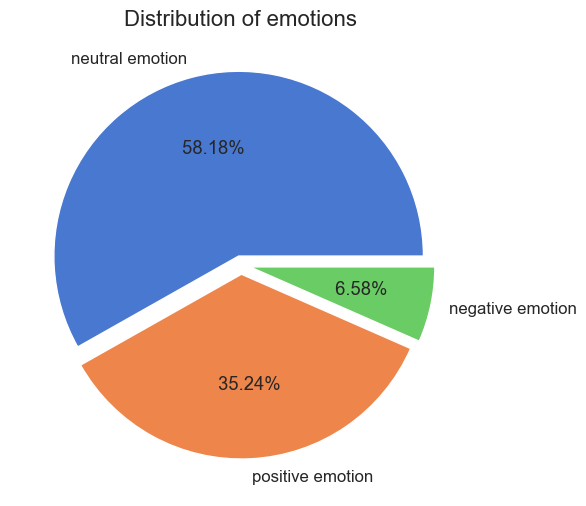

In [31]:
# Creating a pie chart for the target variable
label = ["neutral emotion", "positive emotion", "negative emotion"]
plt.figure(figsize = (6,6))
plt.pie(data["emotion"].value_counts(), labels=label, autopct= " %.2f%%", explode=(0.05, 0.05, 0.05))
plt.title("Distribution of emotions", fontsize = 16)
plt.tight_layout
plt.show;

Observations: 
Neutral emotions had the highest percentage of 58.18% among all emotion categories, positive emotions 35.24%, while negative emotions had the lowest percentage of 6.58 %.
There is class imbalance since the neutral tweets form the majority. This class imblance will be addressed during model training to ensure fair performance across all sentiment categories.

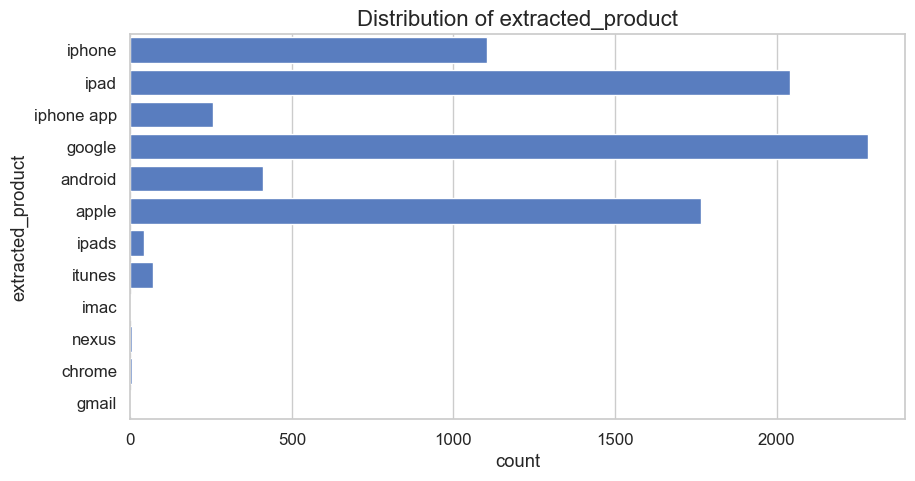

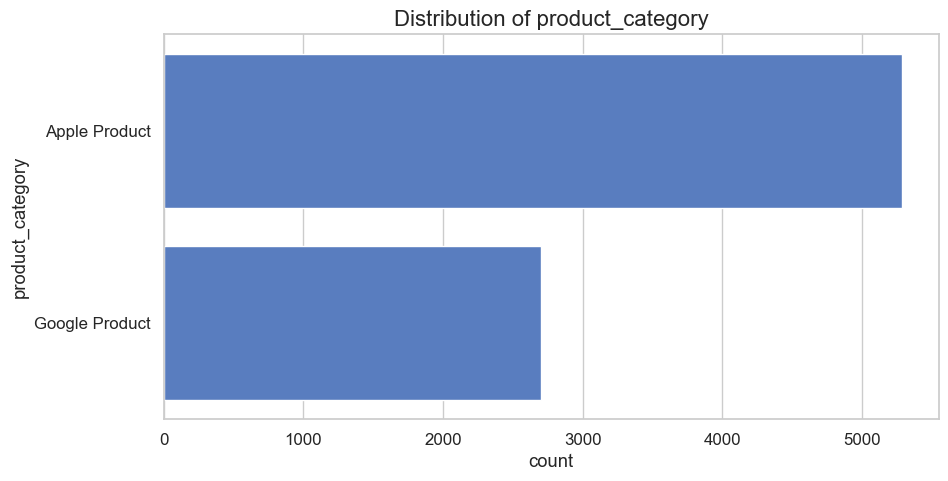

In [32]:
# Using a for loop to create a countplot for the categorical columns
categorical_cols = [
'extracted_product', 'product_category'
 ]
for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(data = data, y= col)
    plt.title(f"Distribution of {col}", fontsize=16)
    plt.show()



Observation of the Extracted Products: 
The extracted_product countplot shows that most tweets mention Google (2,284), second iPad (2,042), third Apple (1,767) and number four iPhone (1,105). The results imply that most user discussions are  focused popular flagship tech products. Further, there were mentions of Android (412),iPhone app (255) while other categories including iTunes, Nexus, and Chrome were rarely in the tweets. Therefore, brand visibility and public engagement are highest for Apple products and Google products.

Observation of the Product Categories:
The product_category countplot shows that Apple products had the highest number of tweets (5,284) while the google products had 2,705 tweets which implies that user discussions are mostly about Apple-related products.

In summary, the users have a high engagement with Apple products. Therefore, there is a potential bias toward Apple in sentiment analysis trends.

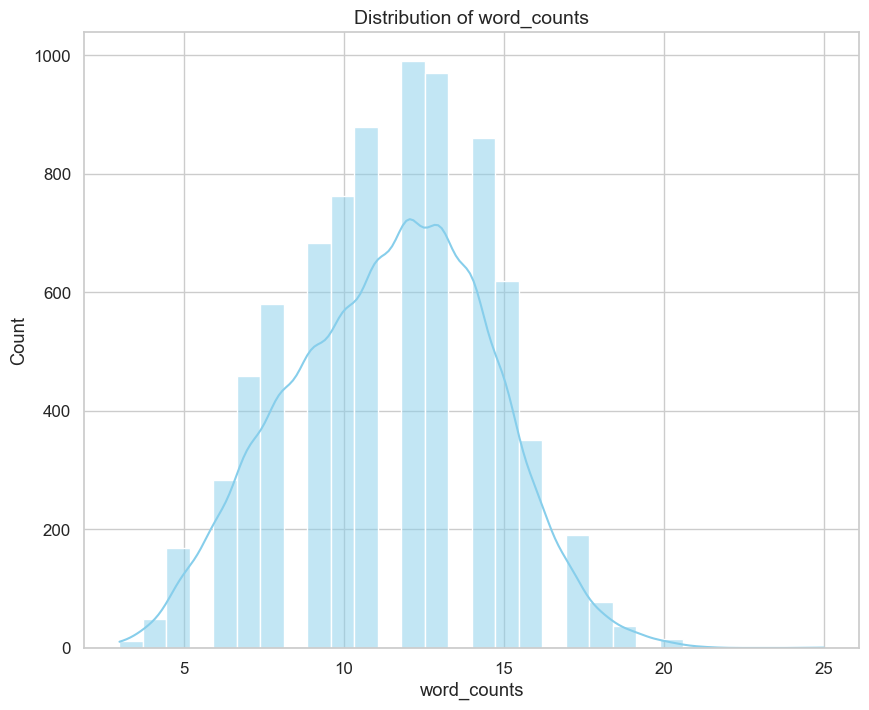

In [33]:
# Creating a histplot for the numerical column
plt.figure(figsize=(10,8))
sns.histplot(data['word_counts'], kde=True, bins=30, color="skyblue")
plt.title(f'Distribution of word_counts', fontsize=14)
plt.xlabel('word_counts')
plt.ylabel('Count')
plt.show();


Observations: 
The histogram shows that the majority of the tweets contain between 10 to 15 words. Majority of the tweets contain approximately 12 and 13 words which implies that most tweets are short and concise sentences typical of social media discussions. The histplot also shows that very few tweets exceed 20 words, showing that longer texts are rare in the dataset. 
In summary, the distribution shows that tweets are generally brief, which supports efficient emotion detection and text processing.

## Bivariate Analysis

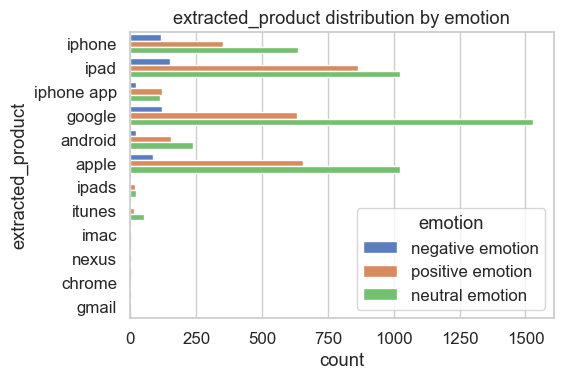

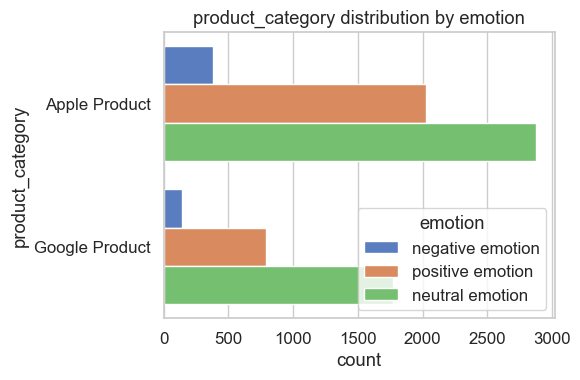

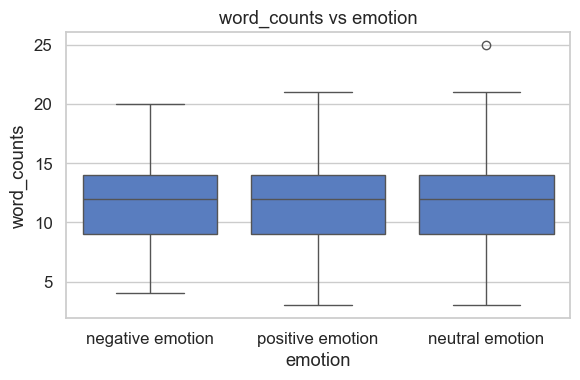

In [34]:
# Using  for loop to plot the categorical and numerical faetures against the target variable
target = 'emotion'  
features = 'extracted_product', 'product_category', 'word_counts'

for col in features:
    plt.figure(figsize=(6,4))
    
    # Numerical features
    if data[col].dtype != 'object':
        sns.boxplot(x = target, y = col, data = data)
        plt.title(f'{col} vs {target}')
    
    # Categorical features
    else:
        sns.countplot(y = col, hue = target, data = data)
        plt.title(f'{col} distribution by {target}')
    
    plt.tight_layout()
    plt.show()


1. extracted_product versus emotion.
The countplot shows that neutral emotions were the highest across all products, especially for Google, apple and iPad. Positive emotions are moderately high among, Google, Apple and iPhone users, while negative emotions have the least number for all the product category.   In summary, the product type slightly influences the emotional tone, with Apple-related products receive a higher share of positive feedback.

2. product_category vs emotion.

The Apple Product category records a higher number of tweets overall, wehere neutral emotions had the highest count, followed  by the positive emotions while the negative emotions had  the lowest count. Google Product tweets had a similar trend but with a slightly smaller share of positive emotions. 
In summary, the plot suggests that Apple products have stronger positive engagement compared to Google products.

3. word_counts vs emotion

The boxplot shows that word counts are moderately consistent across all emotion categories, with most tweets containing around 10 to 13 words. Tweets expressing negative and positive emotions are slightly longer than neutral ones. There are a few outliers in the neutral tweets,   indicating occasional longer expressions of emotion.

## Multivariate Analysis

In [64]:
#Get positve tweets
positive_words = ' '.join([text for text in data['cleaned_tweet_text'][data['emotion'] == 'positive emotion']])

#Get negative tweets
negative_words = ' '.join([text for text in data['cleaned_tweet_text'][data['emotion'] == 'negative emotion']])

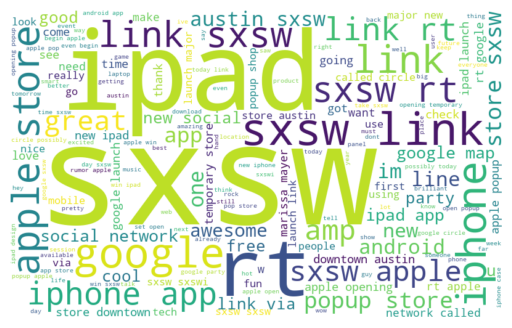

In [36]:
wordcloud = WordCloud(width=800, height=500,
                      background_color='white',
                      min_font_size=10).generate(positive_words)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

Observation:
The word cloud for positive emotions highlights frequently used words that convey satisfaction and approval toward products. The most appearing words in this word cloud are, apple store, apple, google, link, Ipad, iphone app, great, google, cool.

These words especially the large ones, show key themes of appreciation and brand engagement. Therefore, this visualization helps identify the vocabulary commonly associated with positive user sentiment.

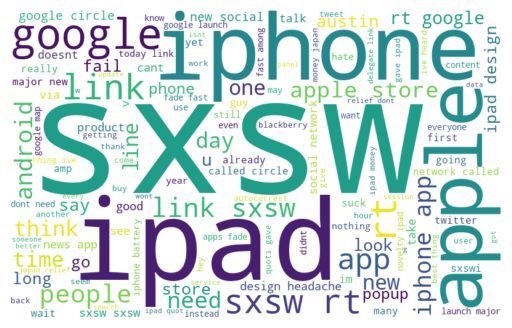

In [37]:
wordcloud = WordCloud(width=800, height=500,
                      background_color='white',
                      min_font_size=10).generate(negative_words)

plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

The negative emotion word cloud highlights frequently used terms that reflect user dissatisfaction and frustration. Such words include, fail, google, iphone, ipad, apple, headache. These words provide the insights into common complaints and recurring issues associated with the products.

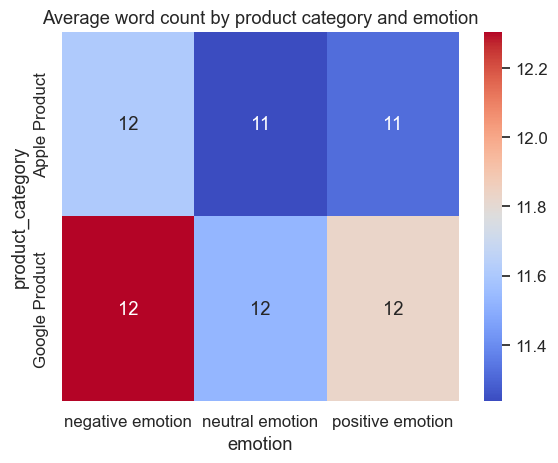

In [38]:
# 
pivot = data.pivot_table(values='word_counts', index='product_category', columns='emotion', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Average word count by product category and emotion')
plt.show()


Observation.
The heatmap shows that average word counts remain fairly consistent across the two categories, product categories and emotion types. The heatmap shows that the words range between 11 and 12 words. This suggests that tweet length does not vary significantly with either emotion or product category.

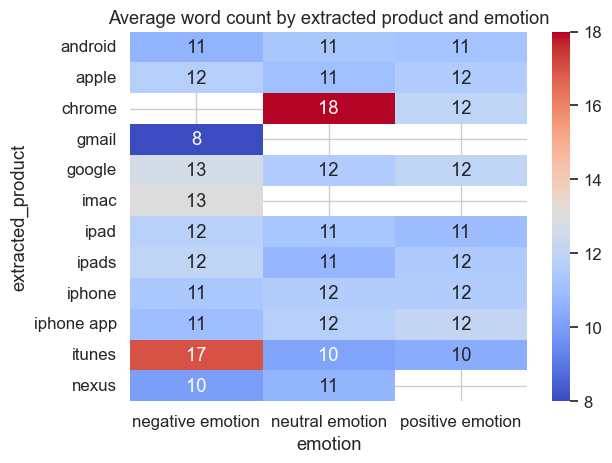

In [39]:
# 
pivot = data.pivot_table(values='word_counts', index='extracted_product', columns='emotion', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Average word count by extracted product and emotion')
plt.show()


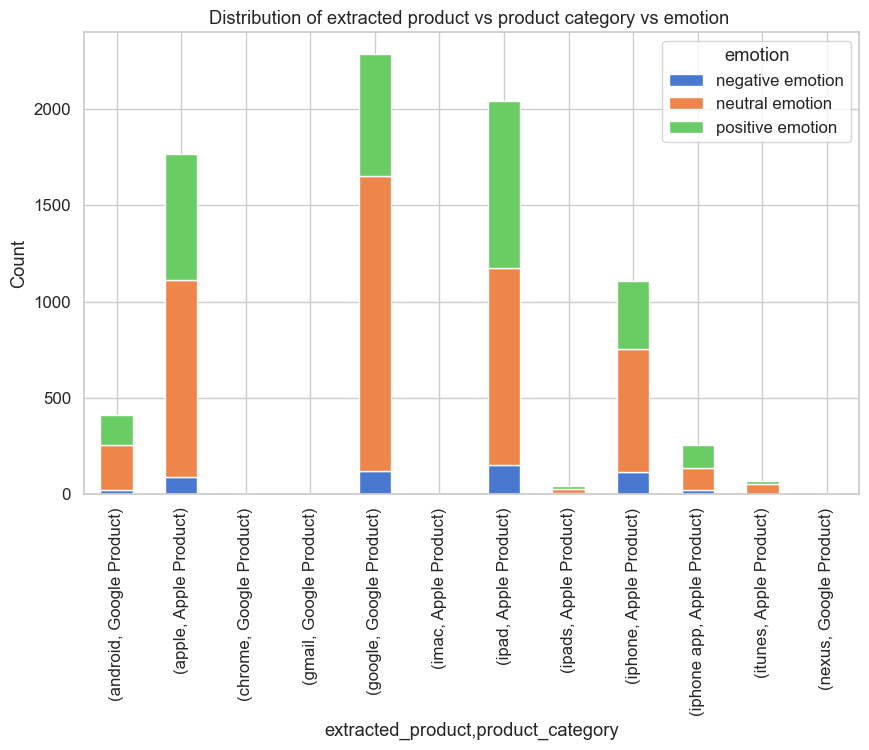

In [65]:
# Creating a crosstab
cross = pd.crosstab([data['extracted_product'], data['product_category']], data['emotion'])

# Plotting a stacked bar
cross.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Distribution of extracted product vs product category vs emotion ')
plt.ylabel('Count')
plt.show()

Observations: 

# Chapter 5: Modeling

## 5.1 Binary Class Modeling

### 5.1.1 Logistic Regression Model

### Vanilla Regression Model - Baseline

In [41]:
#create variable binary data; bin_data
bin_data = data[data["emotion"].isin(["positive emotion","negative emotion"])].copy()

#separate features and labels
X = bin_data["cleaned_tweet_text"].values 
y = (bin_data["emotion"].eq("positive emotion")).astype(int).values  # 1=positive, 0=negative

#split to train and test sets
X_train,X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#create a pipeline for the vanilla model
# vectorize and instantiate logistic regression model
bin_clf = Pipeline([
    ("tfidf", TfidfVectorizer()),#ngram_range=(1,2), min_df=3, max_df=0.95)),
    ("lr",    LogisticRegression())#max_iter=1000, n_jobs=-1, class_weight="balanced")),
])

#train the model
bin_clf.fit(X_train, y_train)

#predict
pred = bin_clf.predict(X_test)

print("\n[BINARY] Test Accuracy:", round(accuracy_score(y_test, pred), 3))
print("[BINARY] Test F1 (binary):", round(f1_score(y_test, pred, average="binary"), 3))
print("\n")
#print classification report
print(classification_report(y_test, pred, target_names=["negative","positive"]))




[BINARY] Test Accuracy: 0.852
[BINARY] Test F1 (binary): 0.919


              precision    recall  f1-score   support

    negative       0.88      0.07      0.12       105
    positive       0.85      1.00      0.92       564

    accuracy                           0.85       669
   macro avg       0.86      0.53      0.52       669
weighted avg       0.86      0.85      0.79       669



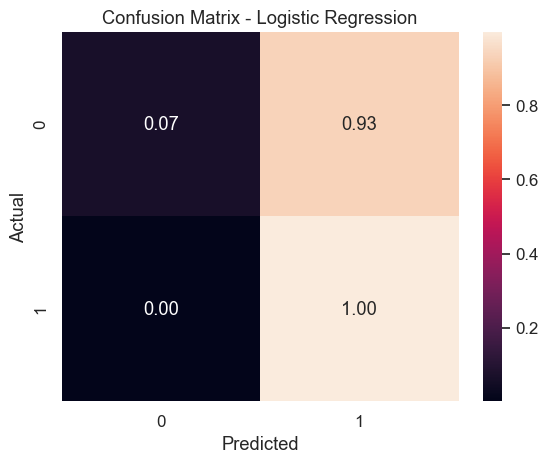

In [42]:
#print confusion matrix
conf_matrix = confusion_matrix(y_test,pred, normalize='true')


sns.heatmap(conf_matrix, annot=True, fmt='.2f')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Observations:
- Class 0:
    - The negative class is mostly misclassified:
    - 93% of actual negative emotions samples are predicted as positive emotions.
    - Only 7% are correctly predicted as negative emotions.
-> This suggests poor precision/recall for negative emotions.

Class 1:
- The positive class is perfectly classified:
    - 100% of actual positive emotions samples are correctly predicted as positive emotions.
    - No misclassifications for positive emotions.
-> Indicates the model is very good at identifying positive emotions.

Potential model bias:
- The model may be biased toward predicting positive emotions, perhaps due to class imbalance or overfitting.

AUC: 0.8900455927051673


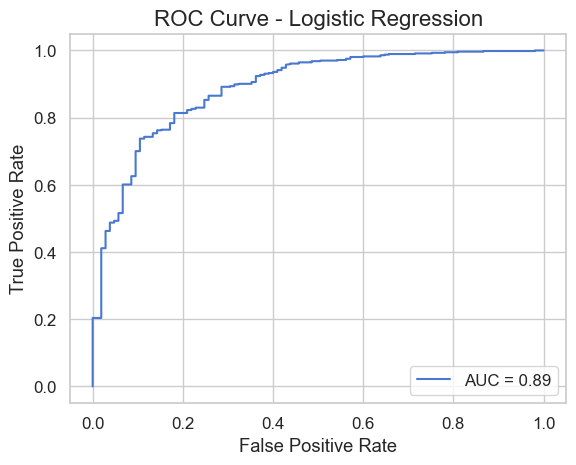

In [43]:
# Check roc
pred_prob = bin_clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

#visualize AUC
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression", fontsize=16)
plt.show()

- We have a high AUC of 0.89, which is nearly perfect:

This means the model has a high ability to distinguish between the two classes.

Specifically, there's an 89% chance the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.

Curve is close to the top-left corner:
    This indicates a strong performance, with high TPR and low FPR.

The model is generally making few false positives while correctly identifying true positives.

Possible imbalance or threshold issue as seen in the confusion matrix:

Despite the high AUC, our confusion matrix shows poor performance on class 0(negative emotions).


### Hyperparameter Tuning the Vanilla  Regression Model with GridSearchCV

In [44]:
param_grid = {
    # TF-IDF vectorizer params
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 3],
    "tfidf__max_df": [0.9, 0.95],
    
    # Logistic Regression params
    "lr__C": [0.1, 1, 10],
    "lr__solver": ["liblinear", "saga"],
    "lr__class_weight": [None, "balanced"],
    "lr__max_iter": [1000, 3000]
}
grid_search = GridSearchCV(
    bin_clf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    verbose=0,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('lr', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'lr__C': [0.1, 1, 10],
                         'lr__class_weight': [None, 'balanced'],
                         'lr__max_iter': [1000, 3000],
                         'lr__solver': ['liblinear', 'saga'],
                         'tfidf__max_df': [0.9, 0.95], 'tfidf__min_df': [1, 3],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1')

In [45]:
print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", round(grid_search.best_score_, 3))



# find best model
best_vanilla_model = grid_search.best_estimator_

#fit the tuned vanilla model
best_vanilla_model.fit(X_train,y_train)

#tuned pred
y_pred_tuned = best_vanilla_model.predict(X_test)



Best Parameters: {'lr__C': 10, 'lr__class_weight': None, 'lr__max_iter': 1000, 'lr__solver': 'saga', 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}
Best F1 Score (CV): 0.932



Classification Report:

              precision    recall  f1-score   support

    negative       0.81      0.41      0.54       105
    positive       0.90      0.98      0.94       564

    accuracy                           0.89       669
   macro avg       0.86      0.70      0.74       669
weighted avg       0.89      0.89      0.88       669



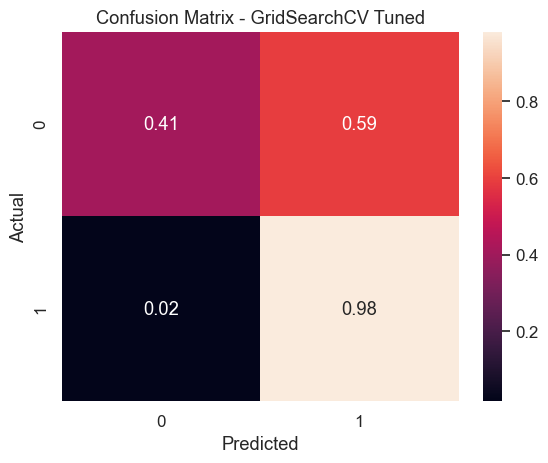

In [46]:
# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tuned, target_names=["negative", "positive"]))

#print confusion matrix
conf_matrix_tuned= confusion_matrix(y_test,y_pred_tuned, normalize='true')
sns.heatmap(conf_matrix_tuned, annot=True, fmt='.2f')
plt.title("Confusion Matrix - GridSearchCV Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
plt.show()


AUC: 0.9129939209726443


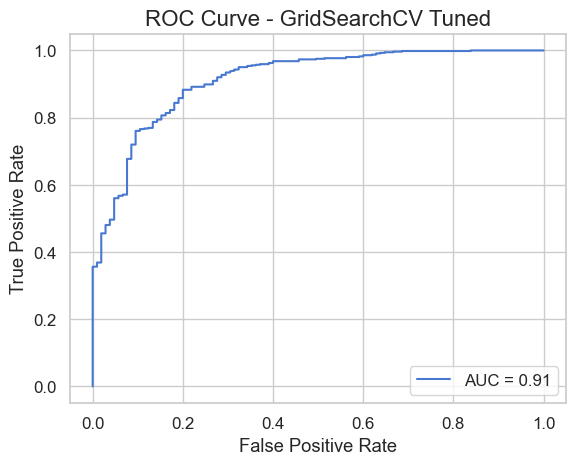

In [47]:
# Check roc
pred_prob_tuned = best_vanilla_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, pred_prob_tuned)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

#visualize AUC
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GridSearchCV Tuned", fontsize=16)
plt.show()

*Observation for the gridsearch tuned model*

Class 1 (Positive) predictions are excellent:
- 98% of actual positive emotions are correctly predicted.
- Only 2% are incorrectly predicted as negative emotions.
-> This means our tuned model is very sensitive to positive cases(high recall).

Class 0 (Negative) performance is weak:
- Only 41% of negative emotions cases are correctly identified.
- 59% are misclassified as class 1 (false positives).
-> This indicates a low precision for positive class.

Bias Toward Class 1:
- The model favors predicting positive emotions, possibly due to:
1. Class imbalance (more positives than negatives in training set).
2. Hyperparameters that over-penalize misclassifying class 1.

### Logistic Regression Model (with balanced class weights and best parameters from GridSearchCV)

In [48]:
# adding weights to the tuned model
bin_clf_tuned = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=1, max_df=0.9)),
    ("lr",    LogisticRegression(max_iter=1000, solver='saga',C=10, class_weight="balanced")),
])

#train the model
bin_clf_tuned.fit(X_train, y_train)

#predict
pred_tuned2 = bin_clf_tuned.predict(X_test)

print("\n[BINARY] Test Accuracy:", round(accuracy_score(y_test, pred_tuned2), 3))
print("[BINARY] Test F1 (binary):", round(f1_score(y_test, pred_tuned2, average="binary"), 3))



[BINARY] Test Accuracy: 0.907
[BINARY] Test F1 (binary): 0.946



Classification Report:

              precision    recall  f1-score   support

    negative       0.73      0.65      0.69       105
    positive       0.94      0.96      0.95       564

    accuracy                           0.91       669
   macro avg       0.83      0.80      0.82       669
weighted avg       0.90      0.91      0.91       669



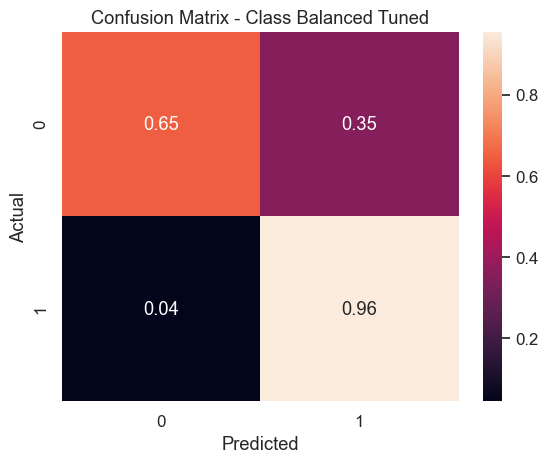

In [49]:
# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, pred_tuned2, target_names=["negative", "positive"]))

#print confusion matrix
conf_matrix_tuned= confusion_matrix(y_test,pred_tuned2, normalize='true')
sns.heatmap(conf_matrix_tuned, annot=True, fmt='.2f')
plt.title("Confusion Matrix - Class Balanced Tuned")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


AUC: 0.9129939209726443


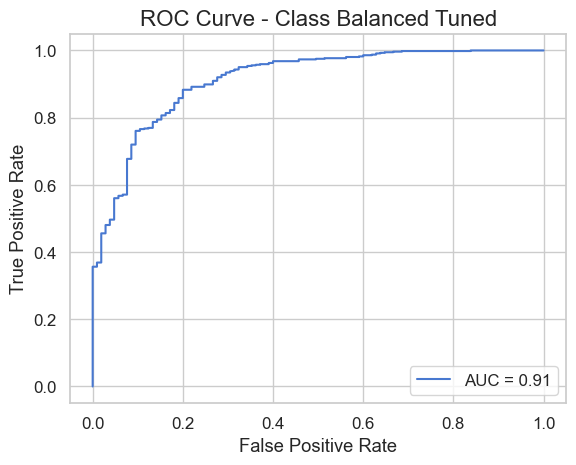

In [50]:
# Check roc
pred_prob_tuned2 = best_vanilla_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, pred_prob_tuned2)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

#visualize AUC
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Class Balanced Tuned", fontsize=16)
plt.show()

Observations:

True Negative Rate (TNR): 65% — 65% of negative tweets are correctly identified.

False Positive Rate (FPR): 35% — 35% of negative tweets are misclassified as positive.

True Positive Rate (TPR / Recall): 96% — the model performs very well at detecting positive tweets.

False Negative Rate (FNR): 4% — very few positive tweets are missed.

Insights:
1. The model still seems to have imbalance where it favors the positive class
2. We should try using other models such as BERT for richer feature representation

### Model Comparison Summary - Logistic Regression (Binary Sentiment)

| Metric | Vanilla Logistic Regression | GridSearchCV (no balancing) | LR (best params + class_weight=balanced) | Observation |
|---|---:|---:|---:|---|
| **Test Accuracy** | 0.852 | 0.890 | 0.910 | Balanced model is highest overall. |
| **Macro Avg F1** *(primary)* | 0.52 | 0.74 | 0.82 | Biggest lift comes from balancing + tuning. |
| **Weighted Avg F1** | 0.79 | 0.88 | 0.91 | Tracks accuracy; reflects majority class. |
| **Precision — Negative (0)** | 0.88| 0.81 | 0.73 | Balancing trades some precision to gain recall. |
| **Recall — Negative (0)** | 0.07 | 0.41 | 0.65 | Critical: far fewer missed complaints. |
| **F1 — Negative (0)** | 0.12 | 0.54 | 0.69 | Negative class improves the most. |
| **Precision — Positive (1)** | 0.85 | 0.90 | 0.94| Highest with balanced tuned model. |
| **Recall — Positive (1)** | 1.00 | 0.98 | 0.96 | Slightly lower but still excellent. |
| **F1 — Positive (1)** | 0.92 | 0.94 | 0.95 | Best overall. |
| **ROC AUC** | 0.89 | ≈0.91 | ≈0.91 | Tuned models separate classes better than vanilla. |
| **Confusion Matrix (rates)** | TN 0.07, FP 0.93; FN 0.00, TP 1.00 | TN 0.41, FP 0.59; FN 0.02, TP 0.98 | TN 0.65, FP 0.35; FN 0.04, TP 0.96 | Balancing sharply reduces errors on negatives. |

**Best logistic regression model (as per our objectives):** Logistic Regression — best params + class_weight=balanced  

**Why??**
- It delivers the top **Macro F1 = 0.82**, better **negative recall = 0.65**, strong **accuracy = 0.91**, and **AUC ≈ 0.91**.
- This meets the project’s focus on balanced performance and catching the rare negative tweets.


### 5.1.2 Naive Bayes Classifier

In [51]:
#vanilla nb 
nb_baseline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB ()) 
])
#train the model
nb_baseline.fit(X_train,y_train)

#predict
nb_pred = nb_baseline.predict(X_test)

print("\n Naive BayesTest Accuracy(binary):", round(accuracy_score(y_test, nb_pred), 3))
print(" Naive Bayes Test F1 (binary):", round(f1_score(y_test, nb_pred, average="binary"), 3))


 Naive BayesTest Accuracy(binary): 0.846
 Naive Bayes Test F1 (binary): 0.916



Classification Report:

              precision    recall  f1-score   support

    negative       1.00      0.02      0.04       105
    positive       0.85      1.00      0.92       564

    accuracy                           0.85       669
   macro avg       0.92      0.51      0.48       669
weighted avg       0.87      0.85      0.78       669



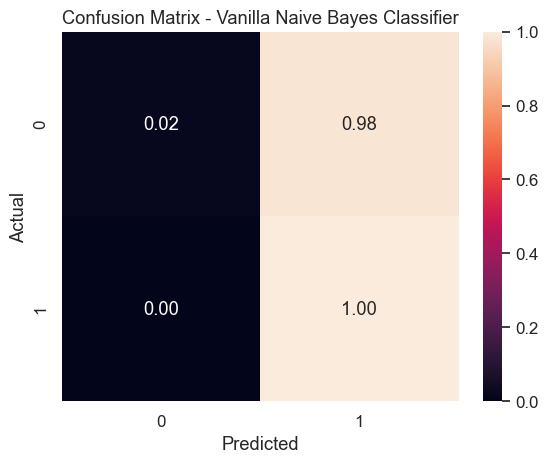

In [52]:
# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, nb_pred, target_names=["negative", "positive"]))

#print confusion matrix
conf_matrix_tuned= confusion_matrix(y_test,nb_pred, normalize='true')
sns.heatmap(conf_matrix_tuned, annot=True, fmt='.2f')
plt.title("Confusion Matrix - Vanilla Naive Bayes Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


AUC: 0.8215889902060114


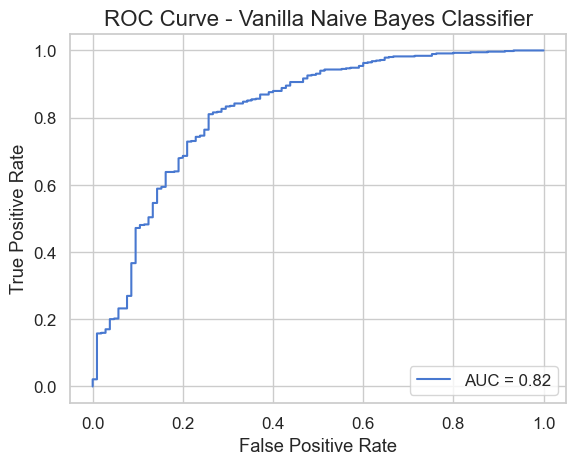

In [53]:
# Check roc
pred_prob_nb = nb_baseline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, pred_prob_nb)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

#visualize AUC
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Vanilla Naive Bayes Classifier", fontsize=16)
plt.show()

### Tuning Naive Bayes Classifier and using SMOTE to deal with class imbalance

In [54]:
#Vectorize
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, max_df=0.9)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

# Balance the training data with SMOTE 
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_vec.toarray(), y_train)

# Define model and parameter grid
nb = MultinomialNB()
param_grid = {
    "alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
}

# --- Grid search ---
grid = GridSearchCV(nb, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train_bal, y_train_bal)

print("Best Params:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 3))

# --- Evaluate on test set ---
best_nb = grid.best_estimator_
y_pred_nb = best_nb.predict(X_test_vec)

print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred_nb), 3))
print("Test F1:", round(f1_score(y_test, y_pred_nb), 3))

Best Params: {'alpha': 0.001}
Best CV F1: 0.969

Test Accuracy: 0.888
Test F1: 0.934



Classification Report:

              precision    recall  f1-score   support

    negative       0.67      0.57      0.62       105
    positive       0.92      0.95      0.93       564

    accuracy                           0.89       669
   macro avg       0.79      0.76      0.77       669
weighted avg       0.88      0.89      0.88       669



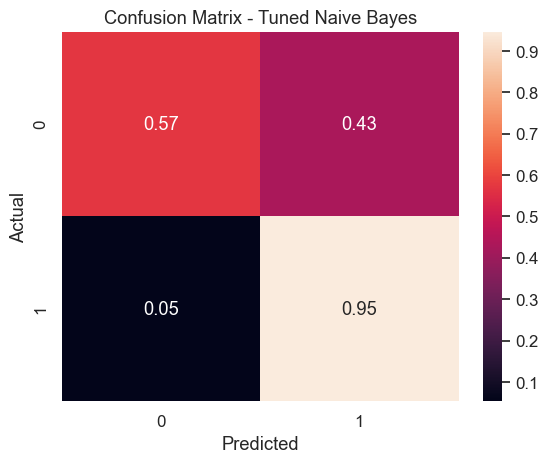

In [55]:
# Evaluation
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb, target_names=["negative", "positive"]))

#print confusion matrix
conf_matrix_tuned2= confusion_matrix(y_test,y_pred_nb, normalize='true')
sns.heatmap(conf_matrix_tuned2, annot=True, fmt='.2f')
plt.title("Confusion Matrix - Tuned Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

AUC: 0.8988770685579196


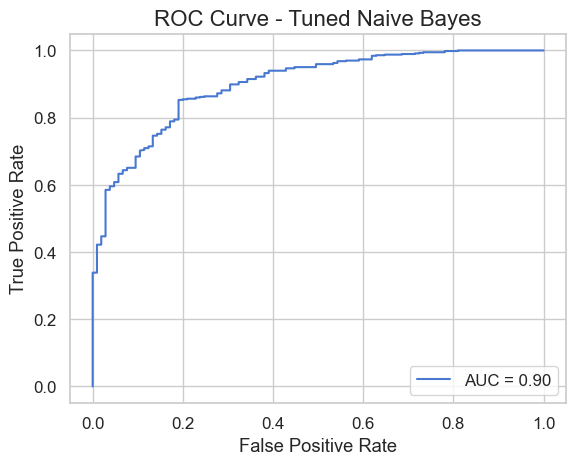

In [56]:
# Check roc
nb_pred_prob_tuned = best_nb.predict_proba(X_test_vec)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, nb_pred_prob_tuned)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

#visualize AUC
plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Naive Bayes", fontsize=16)
plt.show()

### Model Comparison — Naive Bayes (Binary)

| Metric | Naive Bayes (Vanilla) | Naive Bayes (Tuned + SMOTE) | Observation |
|---|---:|---:|---|
| **Test Accuracy** | 0.85 | 0.89 | Tuned+SMOTE improves overall accuracy. |
| **Macro Avg F1** *(primary)* | 0.48 | 0.77 | Huge lift from balancing; far better class parity. |
| **Weighted Avg F1** | 0.78 | 0.88 | Tracks accuracy; improved overall performance. |
| **Precision — Negative (0)** | 1.00 | 0.67 | Vanilla is overconfident on rare negatives when it predicts them. |
| **Recall — Negative (0)** | 0.02 | 0.57 | Critical improvement: far fewer missed complaints. |
| **F1 — Negative (0)** | 0.04 | 0.62 | Negative class benefits the most from SMOTE+tuning. |
| **Precision — Positive (1)** | 0.85 | 0.92 | Better precision on the majority class, too. |
| **Recall — Positive (1)** | 1.00 | 0.95 | Slight drop (expected) to gain negative recall. |
| **F1 — Positive (1)** | 0.92 | 0.93 | Slightly higher after tuning. |
| **ROC AUC** | 0.82 | ≈0.90 | Tuned model separates classes much better. |
| **Confusion Matrix (rates)** | TN 0.02, FP 0.98; FN 0.00, TP 1.00 | TN 0.57, FP 0.43; FN 0.05, TP 0.95 | Tuned+SMOTE meaningfully reduces errors on negatives. |

**Verdict:** **Naive Bayes (Tuned + SMOTE)** clearly aligns better with the business goal of balanced performance and catching negative tweets—**Macro F1 = 0.77** and **Negative recall = 0.57** vs **0.02** for vanilla.


### 5.1.3 LinearSVC Model

### 5.1.4 BiLSTM Model - Deep Learning

### 5.1.5 DistilBERT Model - Transformer

## 5.2 Multi-Class Modeling 

In [57]:
# #B) MULTICLASS: positive / neutral / negative
# # =========================
# mc_df = data[data["emotion"].isin(["positive emotion","neutral emotion","negative emotion"])].copy()
# X_mc = mc_df["cleaned_text"].values
# y_mc = mc_df["emotion"].values

# Xtr, Xte, ytr, yte = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

# mc_clf = Pipeline([
#     ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=3, max_df=0.95)),
#     ("lr",    LogisticRegression(max_iter=1000, n_jobs=-1, class_weight="balanced", multi_class="ovr")),
# ])
# mc_clf.fit(Xtr, ytr)
# pred = mc_clf.predict(Xte)

# print("\n[MULTICLASS] Test Macro-F1:", round(f1_score(yte, pred, average="macro"), 3))
# print(classification_report(yte, pred, digits=3))